In [23]:
import os
print("Current working directory:",os.getcwd())

Current working directory: C:\Users\thors\OneDrive\Desktop\Job\Alberdingk Boley\coatings-ml-project\notebooks


Load Dataset

In [11]:
import pandas as pd

data = pd.read_csv(r"C:\Users\thors\OneDrive\Desktop\Job\Alberdingk Boley\coatings-ml-project\data\coatings_ml_dataset.csv")

data.head()

,binder_type,binder_type_code,crosslinker_pct,wax_pct,Tg_C,solids_pct,coalescent_pct,taber_loss_mg,hardness,VOC_gL
0,Acrylic,1,1.08,1.87,34.0,34.5,4.85,68.3,7.97,76.3
1,Acrylic,1,0.98,1.32,20.7,34.4,4.51,71.4,-3.01,71.6
2,Acrylic,1,1.91,1.11,30.9,29.4,1.40,65.0,7.18,69.8
3,Acrylic,1,2.66,1.06,25.7,34.0,4.75,47.8,7.08,84.6
4,Acrylic,1,1.42,0.48,31.8,34.5,4.45,84.9,5.73,72.7


Explore Dataset

In [12]:
data.describe()

,binder_type_code,crosslinker_pct,wax_pct,Tg_C,solids_pct,coalescent_pct,taber_loss_mg,hardness,VOC_gL
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,1.970000,1.432500,1.058900,29.56200,32.054000,2.815000,66.802000,6.459800,68.998000
std,0.834302,0.865417,0.592326,5.70392,2.527482,1.483616,17.314541,5.847564,7.804854
min,1.000000,0.020000,0.010000,20.30000,28.100000,0.070000,25.800000,-5.590000,49.700000
25%,1.000000,0.717500,0.527500,24.82500,29.700000,1.765000,52.675000,1.980000,63.975000
50%,2.000000,1.475000,1.140000,30.15000,32.000000,2.920000,68.100000,6.865000,67.700000
75%,3.000000,2.190000,1.567500,33.92500,34.300000,4.195000,79.800000,10.702500,74.425000
max,3.000000,2.960000,1.980000,39.50000,35.900000,5.000000,95.700000,16.990000,91.700000


Visualize Dataset

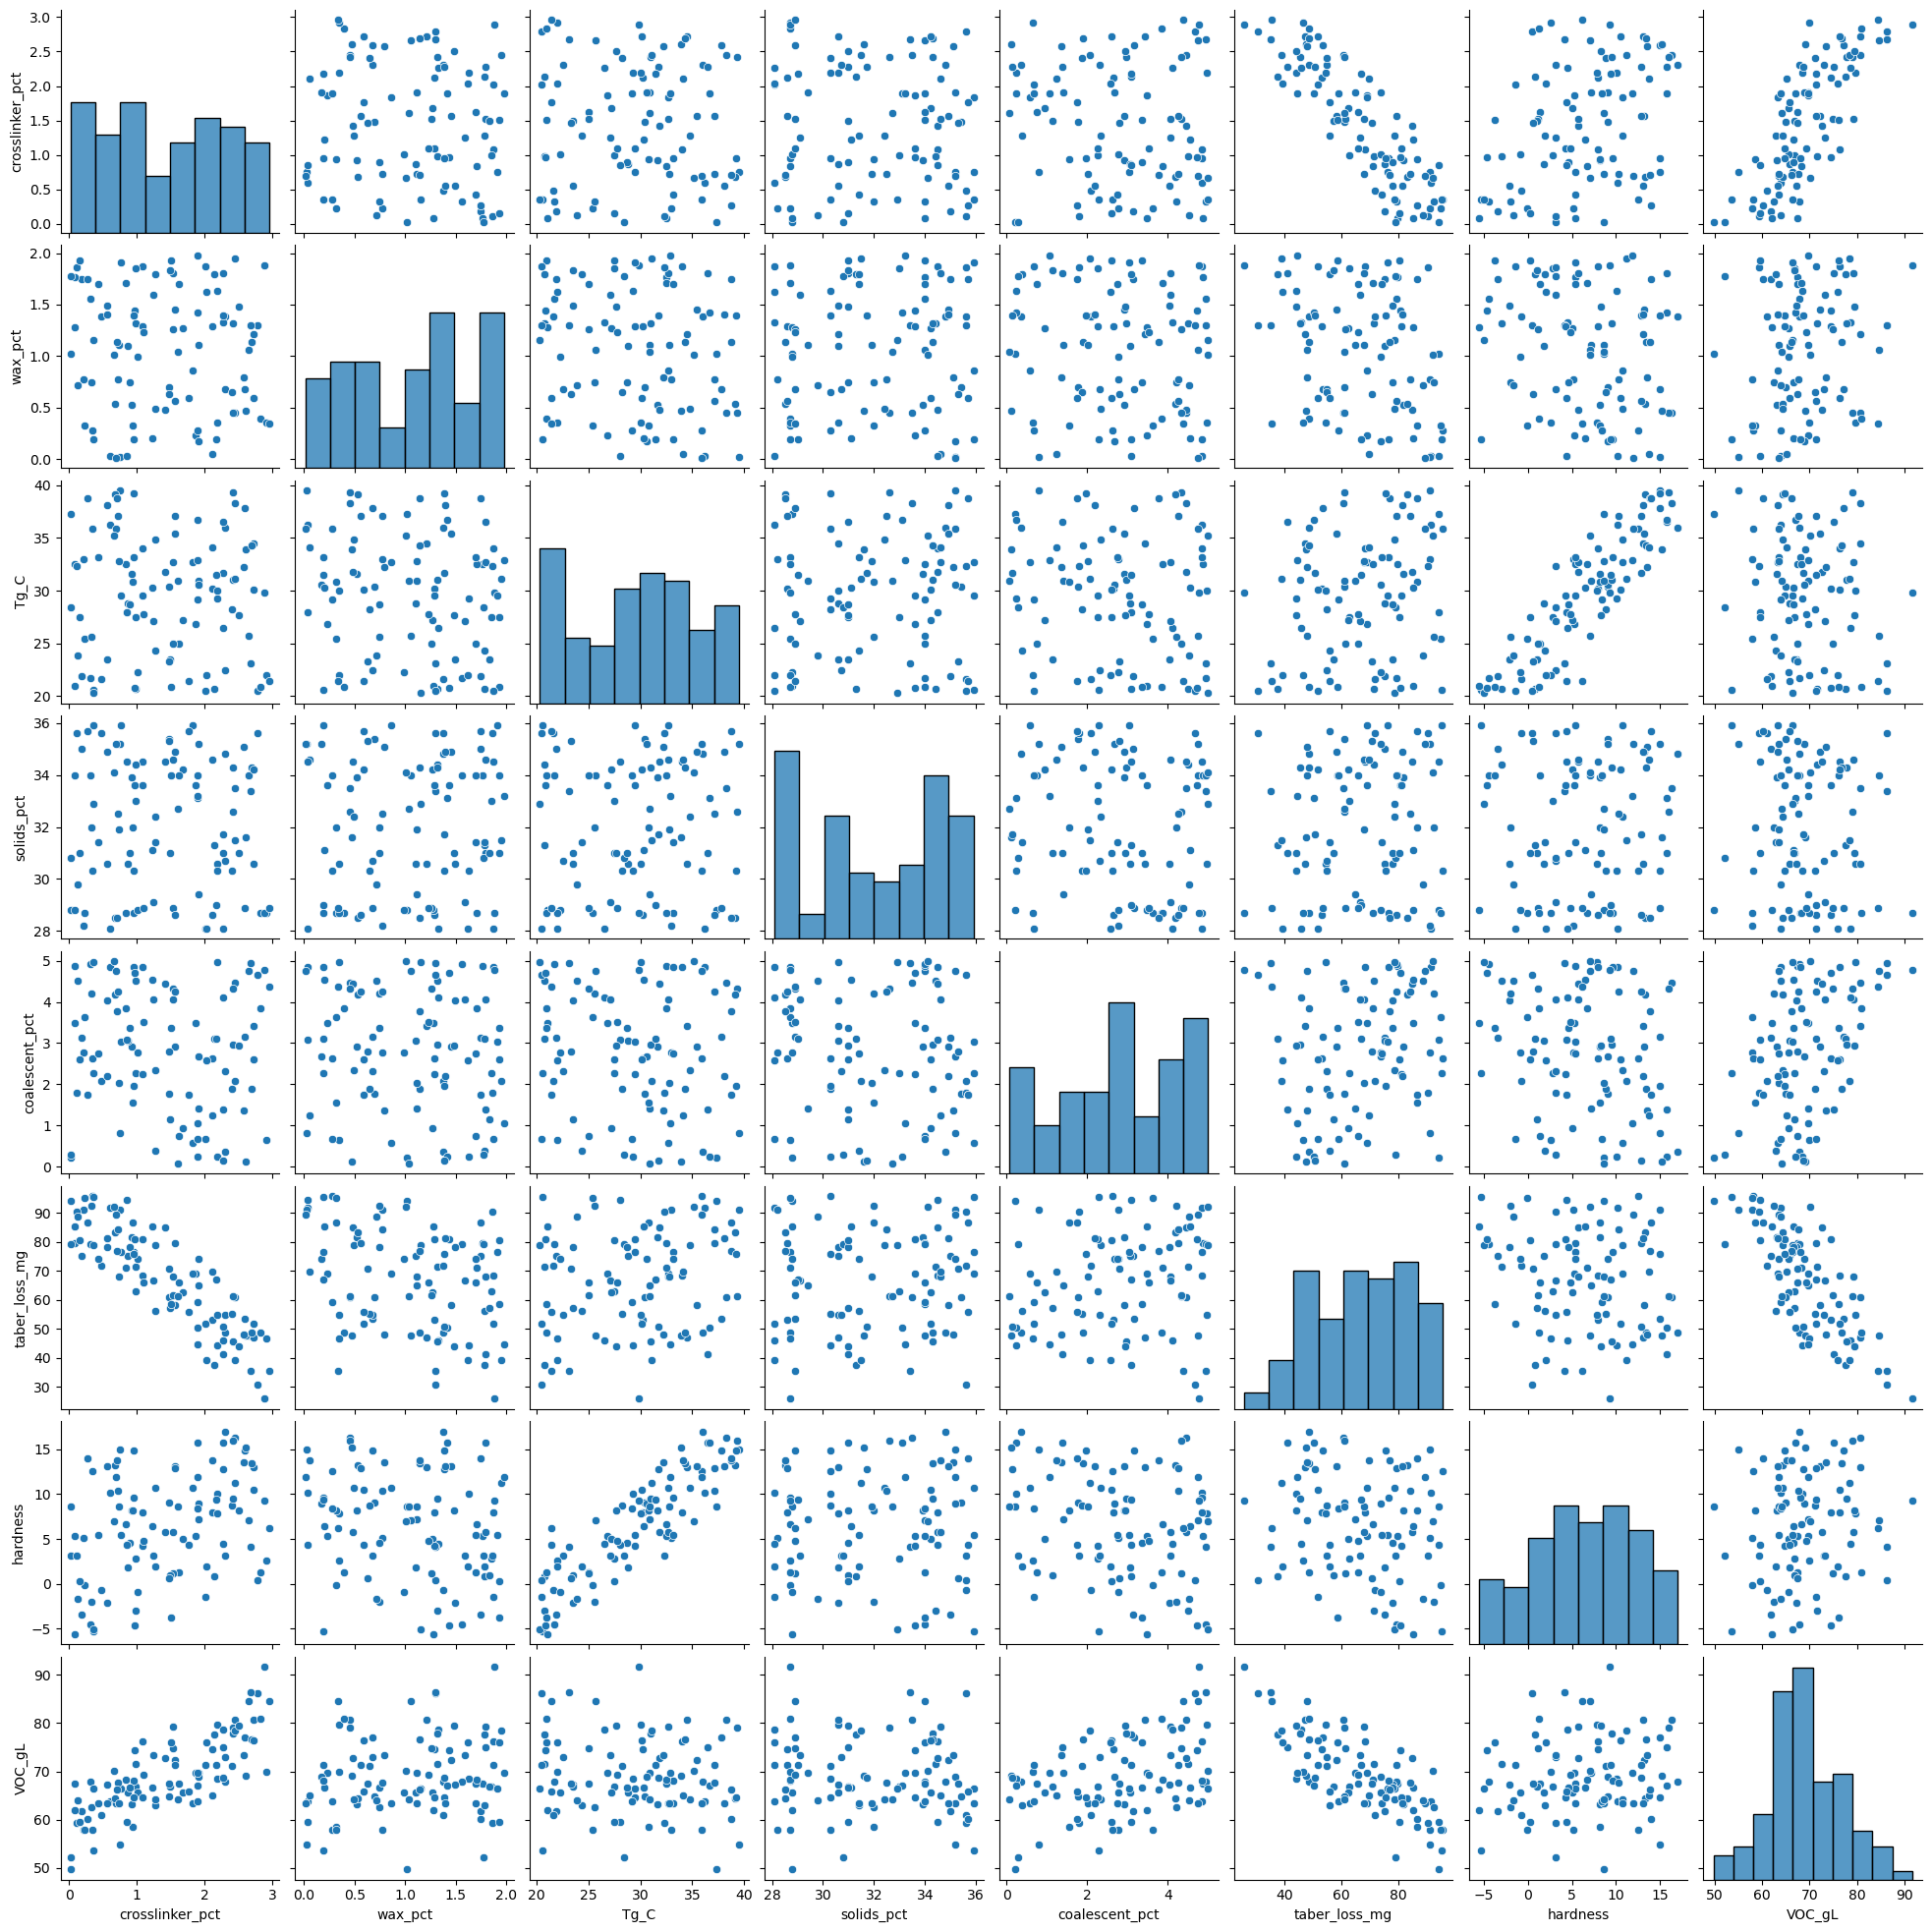

In [27]:
import seaborn as sns

sns.pairplot(data)

Load Libraries

In [40]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

Define Inputs (X) and Multiple Outputs (Y)

In [13]:
X = data[["binder_type_code", "crosslinker_pct", "wax_pct", "Tg_C", "solids_pct", "coalescent_pct"]]   # inputs
Y = data[["taber_loss_mg", "hardness", "VOC_gL"]]  # MULTIPLE outputs

Split Data

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Train Model

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluate Model

In [19]:
from sklearn.metrics import mean_squared_error

Y_pred = model.predict(X_test)
for i, col in enumerate(Y.columns):
    mse = mean_squared_error(Y_test[col], Y_pred[:, i])
    print(f"{col}: MSE = {mse}")

taber_loss_mg: MSE = 61.709688749999906
hardness: MSE = 11.109328109
VOC_gL: MSE = 12.425825399999924


Feature Importance

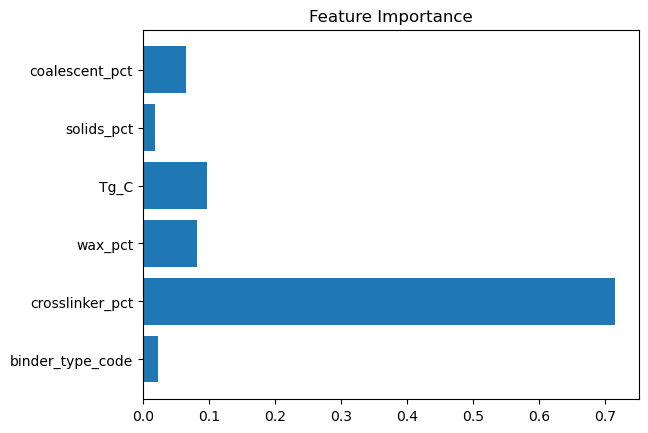

<Figure size 640x480 with 0 Axes>

In [20]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()
plt.savefig("../results/feature_importance.png")

Predict New Formulation

In [26]:
new_sample = pd.DataFrame({
    "binder_type_code": [1],
    "crosslinker_pct": [2],
    "wax_pct": [1],
    "Tg_C": [30],
    "solids_pct": [32],
    "coalescent_pct": [0]
})

prediction = model.predict(new_sample)

print("Predicted Taber Loss, Hardness, VOC:", prediction)

Predicted Taber Loss, Hardness, VOC: [[58.352   7.7709 69.102 ]]
